# PRVNÍ PREDIKCE - Porucha do 72h

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Načtení datasetu
df = pd.read_csv("../data/ML/Predictive_Dataset.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp")
# Kontrola dat
df.head()


,timestamp,machine_id,temperature,vibration,pressure,load,ambient_temperature,is_running,produced_units,defective_units,...,rolling_vibration_std_24h,rolling_pressure_mean_24h,rolling_pressure_std_24h,running_ratio_24h,hours_since_last_failure,failure_count_last_7d,failure_count_last_30d,target_failure_72h,target_failure_type,target_RUL_hours
0,2022-01-01,1,49.3,2.28,4.61,89.27,17.8,1,120,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1617.0
78843,2022-01-01,4,49.3,2.28,4.61,89.27,17.8,1,73,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1296.0
105124,2022-01-01,5,49.3,2.28,4.61,89.27,17.8,1,120,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1818.0
131405,2022-01-01,6,49.3,2.28,4.61,89.27,17.8,1,97,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1110.0
26281,2022-01-01,2,49.3,2.28,4.61,89.27,17.8,1,97,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1242.0


In [2]:
# Namapování názvů linek vůči ID
machine_map = {
    1: "L1 - Řezací stanice",
    2: "L1 - Lis",
    3: "L1 - Montážní stanice",
    4: "L1 - Testovací stanice",
    5: "L2 - Řezací stanice",
    6: "L2 - Lis",
    7: "L2 - Montážní stanice",
    8: "L2 - Testovací stanice",
    9: "L3 - Řezací stanice",
    10: "L3 - Lis",
    11: "L3 - Montážní stanice",
    12: "L3 - Testovací stanice"
}

In [3]:
df.columns

Index(['timestamp', 'machine_id', 'temperature', 'vibration', 'pressure',
       'load', 'ambient_temperature', 'is_running', 'produced_units',
       'defective_units', 'operating_hours_since_maintenance',
       'machine_age_hours', 'health_index', 'health_delta_24h',
       'rolling_temp_mean_24h', 'rolling_temp_std_24h',
       'rolling_vibration_mean_24h', 'rolling_vibration_std_24h',
       'rolling_pressure_mean_24h', 'rolling_pressure_std_24h',
       'running_ratio_24h', 'hours_since_last_failure',
       'failure_count_last_7d', 'failure_count_last_30d', 'target_failure_72h',
       'target_failure_type', 'target_RUL_hours'],
      dtype='str')

In [4]:
# Začátek preprocessingu
# Jen řádky, kde není target NaN
df_model = df.dropna(subset=["target_failure_72h"])

# Doplnění hodnot, kde je hours_since_last_failure NaN pomocí machine_age_hours
df_model["hours_since_last_failure"] = df_model["hours_since_last_failure"].fillna(df_model["machine_age_hours"])

# Výběr features bez nepotřebných sloupců.
features = df_model.columns.drop([
    "timestamp",
    "machine_id",
    "target_failure_72h",
    "target_failure_type",
    "target_RUL_hours",
    "health_index",  # chceme vynechat
    "produced_units",
    "defective_units"
]).tolist()

print(features)

['temperature', 'vibration', 'pressure', 'load', 'ambient_temperature', 'is_running', 'operating_hours_since_maintenance', 'machine_age_hours', 'health_delta_24h', 'rolling_temp_mean_24h', 'rolling_temp_std_24h', 'rolling_vibration_mean_24h', 'rolling_vibration_std_24h', 'rolling_pressure_mean_24h', 'rolling_pressure_std_24h', 'running_ratio_24h', 'hours_since_last_failure', 'failure_count_last_7d', 'failure_count_last_30d']


In [5]:
df_model.shape

(315372, 27)

In [6]:
df_model.isnull().sum()

timestamp                                 0
machine_id                                0
temperature                               0
vibration                                 0
pressure                                  0
load                                      0
ambient_temperature                       0
is_running                                0
produced_units                            0
defective_units                           0
operating_hours_since_maintenance         0
machine_age_hours                         0
health_index                              0
health_delta_24h                        288
rolling_temp_mean_24h                   276
rolling_temp_std_24h                    276
rolling_vibration_mean_24h              276
rolling_vibration_std_24h               276
rolling_pressure_mean_24h               276
rolling_pressure_std_24h                276
running_ratio_24h                       276
hours_since_last_failure                  0
failure_count_last_7d           

In [7]:
# Odstranění NaN hodnot rolling features
df_model = df_model.dropna(subset=features)
df_model = df_model.reset_index(drop=True)

In [8]:
df_model.shape

(315084, 27)

In [9]:
df_model.isnull().sum()

timestamp                                 0
machine_id                                0
temperature                               0
vibration                                 0
pressure                                  0
load                                      0
ambient_temperature                       0
is_running                                0
produced_units                            0
defective_units                           0
operating_hours_since_maintenance         0
machine_age_hours                         0
health_index                              0
health_delta_24h                          0
rolling_temp_mean_24h                     0
rolling_temp_std_24h                      0
rolling_vibration_mean_24h                0
rolling_vibration_std_24h                 0
rolling_pressure_mean_24h                 0
rolling_pressure_std_24h                  0
running_ratio_24h                         0
hours_since_last_failure                  0
failure_count_last_7d           

In [10]:
# Rozdělení datasetu dle času (model se učí na starých datech a testuje na nových)
# Seřazení dat
df_model = df_model.sort_values("timestamp")

# Split podle času
split_time = df_model["timestamp"].quantile(0.8)

train = df_model[df_model["timestamp"] < split_time]
test = df_model[df_model["timestamp"] >= split_time]

# Vytvoření X a y
X_train = train[features]
y_train = train["target_failure_72h"]

X_test = test[features]
y_test = test["target_failure_72h"]

In [11]:
# Logistická regrese
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# škálování
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# model
model_lr = LogisticRegression(max_iter=2000)
model_lr.fit(X_train_scaled, y_train)

pred_lr = model_lr.predict(X_test_scaled)

In [12]:
#Random forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

In [13]:
# Klasifikační model původních modelů
from sklearn.metrics import classification_report

print("=== Logistic Regression ===:")
print(classification_report(y_test, pred_lr))

print("=== Random Forest (Baseline) ===:")
print(classification_report(y_test, pred_rf))

=== Logistic Regression ===:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     56475
           1       0.52      0.99      0.68      6549

    accuracy                           0.90     63024
   macro avg       0.76      0.94      0.81     63024
weighted avg       0.95      0.90      0.92     63024

=== Random Forest (Baseline) ===:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     56475
           1       0.57      0.95      0.71      6549

    accuracy                           0.92     63024
   macro avg       0.78      0.93      0.83     63024
weighted avg       0.95      0.92      0.93     63024



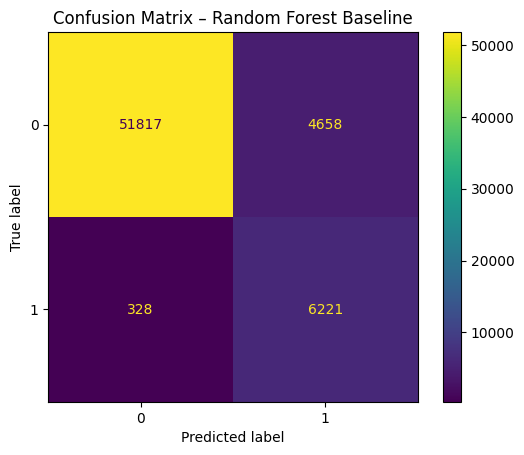

In [14]:
# Confusion metrix původního Random forest
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)
plt.title("Confusion Matrix – Random Forest Baseline")
plt.show()

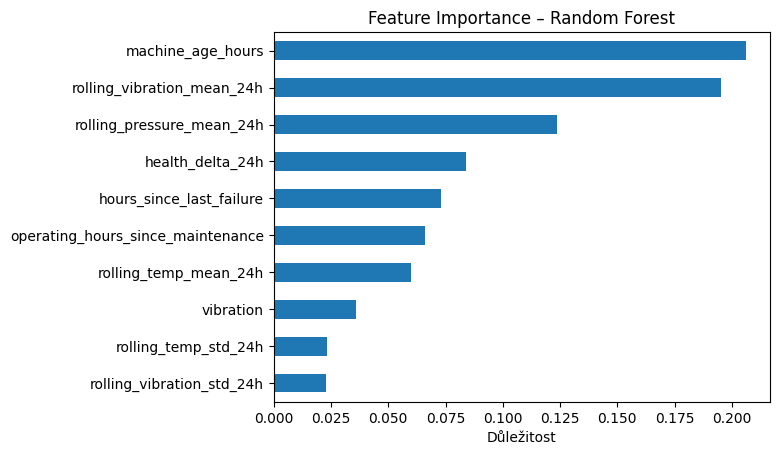

In [15]:
# Feature importance původní model
import pandas as pd

importance = pd.Series(
    model_rf.feature_importances_,
    index=features
).sort_values(ascending=False)

importance.head(10).plot(kind="barh")
plt.title("Feature Importance – Random Forest")
plt.xlabel("Důležitost")
plt.gca().invert_yaxis()
plt.show()

In [16]:
# Random forest tuning
from sklearn.ensemble import RandomForestClassifier

model_rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model_rf_tuned.fit(X_train, y_train)

proba_rf_tuned = model_rf_tuned.predict_proba(X_test)[:, 1]

pred_rf_tuned = model_rf_tuned.predict(X_test)

In [17]:
#Klasifikační report starého a tuned random forest
from sklearn.metrics import classification_report

print("=== Random Forest (Baseline) ===:")
print(classification_report(y_test, pred_rf))

print("=== Random Forest (Tuned) ===")
print(classification_report(y_test, pred_rf_tuned))

=== Random Forest (Baseline) ===:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     56475
           1       0.57      0.95      0.71      6549

    accuracy                           0.92     63024
   macro avg       0.78      0.93      0.83     63024
weighted avg       0.95      0.92      0.93     63024

=== Random Forest (Tuned) ===
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     56475
           1       0.60      0.93      0.73      6549

    accuracy                           0.93     63024
   macro avg       0.80      0.93      0.85     63024
weighted avg       0.95      0.93      0.94     63024



Nejlépe vyšel RF Tuned

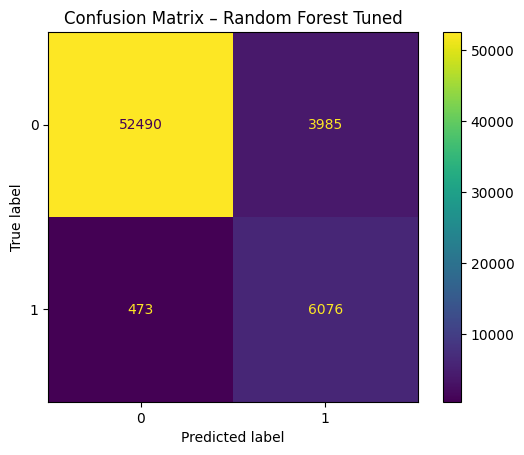

In [18]:
# Confusion matrix tuned Random forest
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, pred_rf_tuned)
plt.title("Confusion Matrix – Random Forest Tuned")
plt.show()

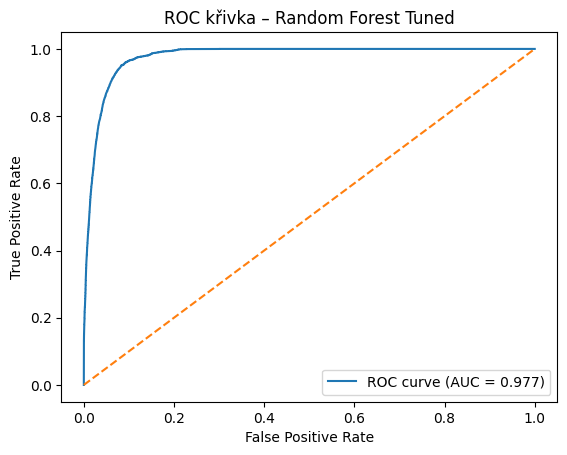

In [19]:
#ROC a AUC curve tuned Random Forest
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

proba_rf_tuned = model_rf_tuned.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, proba_rf_tuned)
auc = roc_auc_score(y_test, proba_rf_tuned)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC křivka – Random Forest Tuned")
plt.legend()
plt.show()

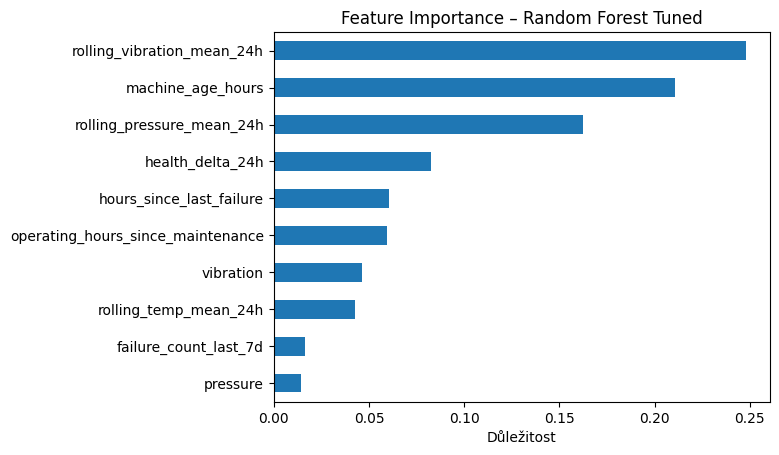

In [20]:
# Feature importance tuned Random Forest
import pandas as pd

importance = pd.Series(
    model_rf_tuned.feature_importances_,
    index=features
).sort_values(ascending=False)

importance.head(10).plot(kind="barh")
plt.title("Feature Importance – Random Forest Tuned")
plt.xlabel("Důležitost")
plt.gca().invert_yaxis()
plt.show()

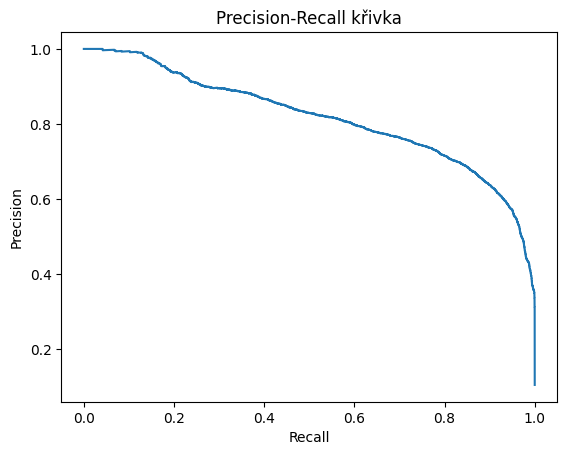

In [ ]:
# Precision Recall curve tuned Random Forest
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, proba_rf_tuned)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall křivka")
plt.show()

In [22]:
# Úpravy threshold pro tuned Random Forest
proba_rf_tuned = model_rf_tuned.predict_proba(X_test)[:, 1]

pred_rf_custom = (proba_rf_tuned > 0.3).astype(int)


In [23]:
# Klasifikační report tuned a vlastní threshold Random Forest
from sklearn.metrics import classification_report

print("=== Random Forest (Tuned) ===")
print(classification_report(y_test, pred_rf_tuned))

print("=== Random Forest (Threshold 0.3) ===")
print(classification_report(y_test, pred_rf_custom))

=== Random Forest (Tuned) ===
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     56475
           1       0.60      0.93      0.73      6549

    accuracy                           0.93     63024
   macro avg       0.80      0.93      0.85     63024
weighted avg       0.95      0.93      0.94     63024

=== Random Forest (Threshold 0.3) ===
              precision    recall  f1-score   support

           0       1.00      0.87      0.93     56475
           1       0.46      0.98      0.63      6549

    accuracy                           0.88     63024
   macro avg       0.73      0.92      0.78     63024
weighted avg       0.94      0.88      0.90     63024



Možnost / Pokus pro úpravu threshold pro RF Tuned. Snížení threshold způsobí méně nezachycených poruch, ale naopak mnohem větší množství falešných poplachů. Lze nastavit dle strategie, zda je horší finančně nezachycení poruch či náklady na zbytečné zásahy na falšené poruchy.

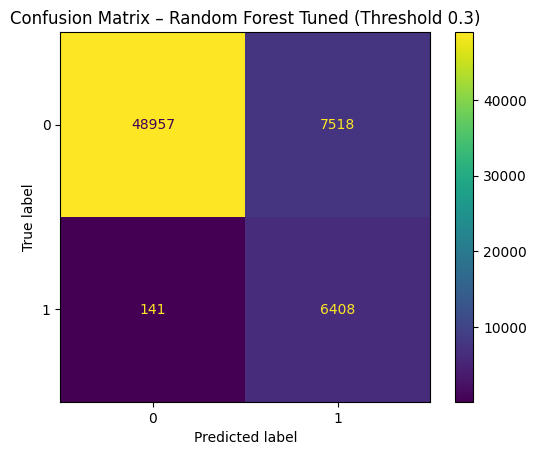

In [24]:
# Confusion Martrix vlastního threshold
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, pred_rf_custom)
plt.title("Confusion Matrix – Random Forest Tuned (Threshold 0.3)")
plt.show()

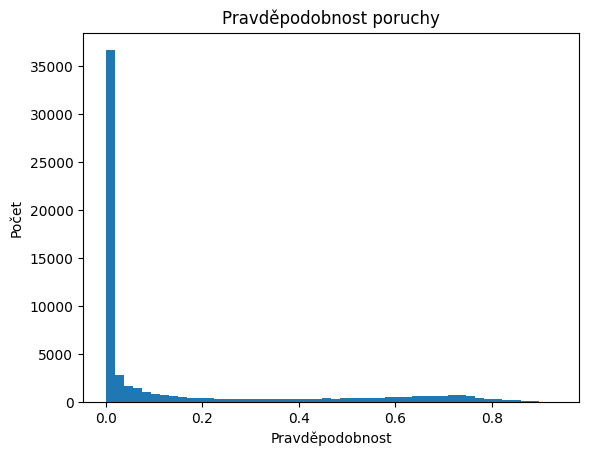

In [25]:
# Celková pravděpodobnost poruch v datech
probs = model_rf_tuned.predict_proba(X_test)[:,1]

import matplotlib.pyplot as plt

plt.hist(probs, bins=50)
plt.title("Pravděpodobnost poruchy")
plt.xlabel("Pravděpodobnost")
plt.ylabel("Počet")
plt.show()

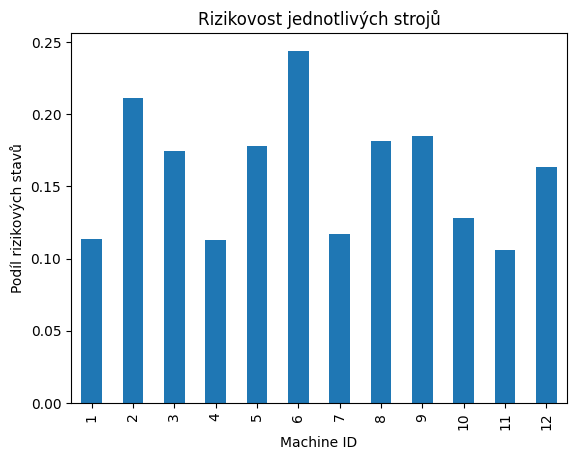

In [26]:
#Rizikovost jednotlivých strojů
import matplotlib.pyplot as plt

test_results = test.copy()
test_results["prediction"] = pred_rf_tuned

risk = test_results.groupby("machine_id")["prediction"].mean()

risk.plot(kind="bar")
plt.title("Rizikovost jednotlivých strojů")
plt.xlabel("Machine ID")
plt.ylabel("Podíl rizikových stavů")
plt.show()

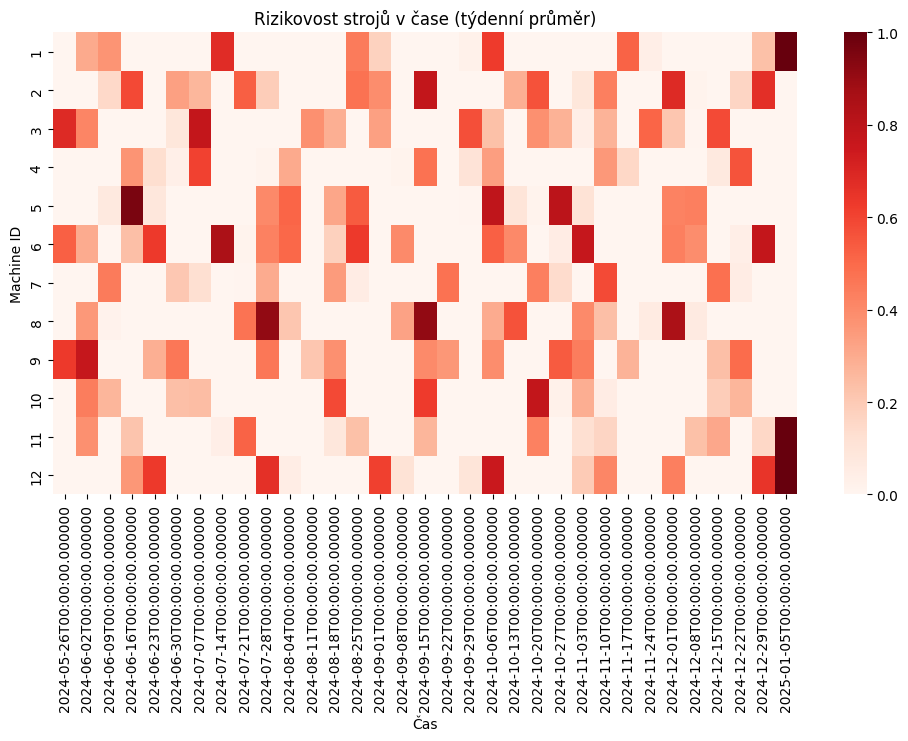

In [27]:
# Problémovost / riziko historicky - doplňkové pro analýzu trendů
pivot = test_results.pivot_table(
    index="timestamp",
    columns="machine_id",
    values="prediction"
)

pivot_weekly = pivot.resample("W").mean()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(pivot_weekly.T, cmap="Reds")
plt.title("Rizikovost strojů v čase (týdenní průměr)")
plt.xlabel("Čas")
plt.ylabel("Machine ID")
plt.show()

In [50]:
# Tabulka predikující potenciální poruchu a pravděpodobnost poruchy
# 1) přidání pravděpodobností
#test_results = test.copy()

#test_results["prediction"] = pred_rf_tuned
test_results["probability"] = model_rf_tuned.predict_proba(X_test)[:, 1]


# 2) poslední záznam pro každý stroj
latest = (
    test_results
    .sort_values("timestamp")
    .groupby("machine_id")
    .tail(1)
    .copy()
)


# 3) %
latest["probability_pct"] = (latest["probability"] * 100).round(1)


# 4) risk level
latest["risk_level"] = latest["probability"].apply(
    lambda x: "🔴 VYSOKÁ" if x > 0.7 else ("🟠 STŘEDNÍ" if x > 0.4 else "🟢 NÍZKÁ")
)


# 5) finální tabulka (zatím původní názvy!)
final_table = (
    latest[[
        "machine_id",
        "prediction",
        "probability_pct",
        "risk_level"
    ]]
    .sort_values("probability_pct", ascending=False)
    .reset_index(drop=True)
)


# 🔥 6) přidání YES/NO (správně!)
final_table["prediction_text"] = final_table["prediction"].map({
    1: "ANO",
    0: "NE"
})

final_table["machine_name"] = final_table["machine_id"].map(machine_map)


# 🔥 7) přeuspořádání sloupců (aby to bylo hezké)
final_table = final_table[[
    "machine_id",
    "machine_name",
    "prediction",
    "prediction_text",
    "probability_pct",
    "risk_level"
]]

final_table["probability_pct"] = final_table["probability_pct"].clip(lower=0.1)


# 🔥 8) přejmenování až na konci
final_table.columns = [
    "Stroj ID",
    "Stroj název",
    "Predikce poruchy (0/1)",
    "Predikce poruchy (ANO/NE)",
    "Riziko poruchy do 72 h (%)",
    "Úroveň rizika"
]


final_table.to_csv("failure_predictions.csv", index=False)
# 9) výstup
final_table

,Stroj ID,Stroj název,Predikce poruchy (0/1),Predikce poruchy (ANO/NE),Riziko poruchy do 72 h (%),Úroveň rizika
0,1,L1 - Řezací stanice,1,ANO,77.1,🔴 VYSOKÁ
1,12,L3 - Testovací stanice,1,ANO,71.9,🔴 VYSOKÁ
2,11,L3 - Montážní stanice,1,ANO,50.9,🟠 STŘEDNÍ
3,3,L1 - Montážní stanice,0,NE,10.8,🟢 NÍZKÁ
4,5,L2 - Řezací stanice,0,NE,2.7,🟢 NÍZKÁ
5,7,L2 - Montážní stanice,0,NE,1.7,🟢 NÍZKÁ
6,6,L2 - Lis,0,NE,0.1,🟢 NÍZKÁ
7,10,L3 - Lis,0,NE,0.1,🟢 NÍZKÁ
8,9,L3 - Řezací stanice,0,NE,0.1,🟢 NÍZKÁ
9,2,L1 - Lis,0,NE,0.1,🟢 NÍZKÁ


## XGBoost model TEST - vyšel s horšími výsledky než Random Forest

Tahle sekce je oddělená od původních modelů a kopíruje stejný postup jako předchozí modely, jen místo nich používá `XGBClassifier`.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Načtení datasetu
df_xgb = pd.read_csv("../data/ML/Predictive_Dataset.csv", parse_dates=["timestamp"])
df_xgb = df_xgb.sort_values("timestamp")

# Kontrola dat
df_xgb.head()


,timestamp,machine_id,temperature,vibration,pressure,load,ambient_temperature,is_running,produced_units,defective_units,...,rolling_vibration_std_24h,rolling_pressure_mean_24h,rolling_pressure_std_24h,running_ratio_24h,hours_since_last_failure,failure_count_last_7d,failure_count_last_30d,target_failure_72h,target_failure_type,target_RUL_hours
0,2022-01-01,1,49.3,2.28,4.61,89.27,17.8,1,120,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1617.0
78843,2022-01-01,4,49.3,2.28,4.61,89.27,17.8,1,73,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1296.0
105124,2022-01-01,5,49.3,2.28,4.61,89.27,17.8,1,120,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1818.0
131405,2022-01-01,6,49.3,2.28,4.61,89.27,17.8,1,97,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1110.0
26281,2022-01-01,2,49.3,2.28,4.61,89.27,17.8,1,97,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1242.0


In [30]:
# Začátek preprocessingu

df_xgb_model = df_xgb.dropna(subset=["target_failure_72h"])

# Doplnění hodnot, kde je hours_since_last_failure NaN pomocí machine_age_hours
df_xgb_model["hours_since_last_failure"] = df_xgb_model["hours_since_last_failure"].fillna(df_xgb_model["machine_age_hours"])

# Výběr features bez nepotřebných sloupců.
features_xgb = df_xgb_model.columns.drop([
    "timestamp",
    "machine_id",
    "target_failure_72h",
    "target_failure_type",
    "target_RUL_hours",
    "health_index",
    "produced_units",
    "defective_units"
]).tolist()

print(features_xgb)


['temperature', 'vibration', 'pressure', 'load', 'ambient_temperature', 'is_running', 'operating_hours_since_maintenance', 'machine_age_hours', 'health_delta_24h', 'rolling_temp_mean_24h', 'rolling_temp_std_24h', 'rolling_vibration_mean_24h', 'rolling_vibration_std_24h', 'rolling_pressure_mean_24h', 'rolling_pressure_std_24h', 'running_ratio_24h', 'hours_since_last_failure', 'failure_count_last_7d', 'failure_count_last_30d']


In [31]:
df_xgb_model.shape


(315372, 27)

In [32]:
df_xgb_model.isnull().sum()


timestamp                                 0
machine_id                                0
temperature                               0
vibration                                 0
pressure                                  0
load                                      0
ambient_temperature                       0
is_running                                0
produced_units                            0
defective_units                           0
operating_hours_since_maintenance         0
machine_age_hours                         0
health_index                              0
health_delta_24h                        288
rolling_temp_mean_24h                   276
rolling_temp_std_24h                    276
rolling_vibration_mean_24h              276
rolling_vibration_std_24h               276
rolling_pressure_mean_24h               276
rolling_pressure_std_24h                276
running_ratio_24h                       276
hours_since_last_failure                  0
failure_count_last_7d           

In [33]:
# Odstranění NaN hodnot rolling features
df_xgb_model = df_xgb_model.dropna(subset=features_xgb)
df_xgb_model = df_xgb_model.reset_index(drop=True)


In [34]:
df_xgb_model.shape


(315084, 27)

In [35]:
df_xgb_model.isnull().sum()


timestamp                                 0
machine_id                                0
temperature                               0
vibration                                 0
pressure                                  0
load                                      0
ambient_temperature                       0
is_running                                0
produced_units                            0
defective_units                           0
operating_hours_since_maintenance         0
machine_age_hours                         0
health_index                              0
health_delta_24h                          0
rolling_temp_mean_24h                     0
rolling_temp_std_24h                      0
rolling_vibration_mean_24h                0
rolling_vibration_std_24h                 0
rolling_pressure_mean_24h                 0
rolling_pressure_std_24h                  0
running_ratio_24h                         0
hours_since_last_failure                  0
failure_count_last_7d           

In [36]:
# Rozdělení datasetu dle času (model se učí na starých datech a testuje na nových)
# Seřazení dat
df_xgb_model = df_xgb_model.sort_values("timestamp")

# Split podle času
split_time_xgb = df_xgb_model["timestamp"].quantile(0.8)

train_xgb = df_xgb_model[df_xgb_model["timestamp"] < split_time_xgb]
test_xgb = df_xgb_model[df_xgb_model["timestamp"] >= split_time_xgb]

# Vytvoření X a y
X_train_xgb = train_xgb[features_xgb]
y_train_xgb = train_xgb["target_failure_72h"]

X_test_xgb = test_xgb[features_xgb]
y_test_xgb = test_xgb["target_failure_72h"]


In [37]:
# XGBoost
model_xgb = XGBClassifier(random_state=42, eval_metric="logloss")
model_xgb.fit(X_train_xgb, y_train_xgb)

pred_xgb = model_xgb.predict(X_test_xgb)


In [38]:
# Klasifikační model XGBoost
from sklearn.metrics import classification_report

print("=== XGBoost ===:")
print(classification_report(y_test_xgb, pred_xgb))


=== XGBoost ===:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     56475
           1       0.55      0.94      0.70      6549

    accuracy                           0.91     63024
   macro avg       0.77      0.93      0.82     63024
weighted avg       0.95      0.91      0.92     63024



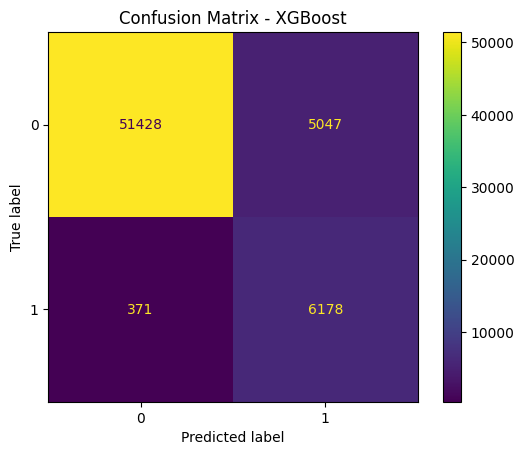

In [39]:
# Confusion metrix XGBoost
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test_xgb, pred_xgb)
plt.title("Confusion Matrix - XGBoost")
plt.show()


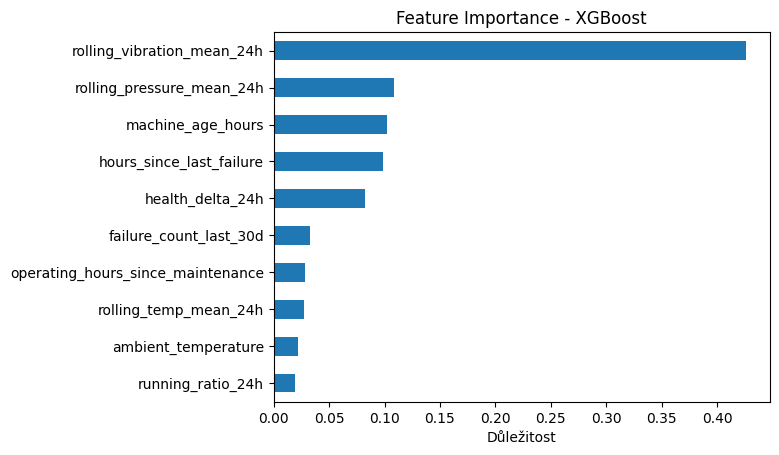

In [40]:
# Feature importance XGBoost
importance_xgb = pd.Series(
    model_xgb.feature_importances_,
    index=features_xgb
).sort_values(ascending=False)

importance_xgb.head(10).plot(kind="barh")
plt.title("Feature Importance - XGBoost")
plt.xlabel("Důležitost")
plt.gca().invert_yaxis()
plt.show()
